# Train Gothic SW/RGB Temperature-Binned Decision Trees

This notebook builds a 5-minute training table for Gothic using:

- GOES RGB domain-mean red/green/blue values within -106.93268W to -107.04666W and 38.95834N to 38.91294N.
- SW-derived cloud labels from ARM Gothic `gucsebsM1.b1` daily `down_short_hemisp` files and Metsim clear-sky SW.
- ERA5 hourly 2 m temperature (`t2m`), interpolated to 5-minute label times, for temperature-bin assignment.

Only 09:00-14:00 Mountain Time is used. The date window is October 2021 through June 2023, limited to overlapping RGB/SW timesteps. Each labeled SW timestep is matched to exactly one nearest RGB timestep. SW ratio labels use Metsim `TBASE = 0.95`: cloudy when `SWobs / SWclear < 0.40`, clear when `SWobs / SWclear > 0.80`, and ambiguous timesteps are discarded.

The decision trees are trained separately for ERA5-temperature bins: `<-10C`, `[-10, 0)`, `[0, 10)`, and `>=10C`.

In [1]:
from pathlib import Path

ROOT = Path('/glade/u/home/cdalden/goes_work/analysis')
SCRIPT = ROOT / 'train_gothic_sw_rgb_tempbin_trees.py'
PYTHON = Path('/glade/work/cdalden/conda-envs/goes_analysis/bin/python')
OUT_DIR = ROOT / 'output_11d_gothic'

assert SCRIPT.exists(), SCRIPT
assert PYTHON.exists(), PYTHON
OUT_DIR.mkdir(exist_ok=True)

print('Script:', SCRIPT)
print('Python:', PYTHON)
print('Output:', OUT_DIR)

Script: /glade/u/home/cdalden/goes_work/analysis/train_gothic_sw_rgb_tempbin_trees.py
Python: /glade/work/cdalden/conda-envs/goes_analysis/bin/python
Output: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic


In [2]:
import subprocess

result = subprocess.run(
    [str(PYTHON), str(SCRIPT)],
    cwd=str(ROOT),
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
result.check_returncode()

Reusing RGB domain means: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic/gothic_rgb_SW_domain.csv (38857 rows)
Loaded SW daily files from /glade/u/home/cdalden/scratch/surface_obs/colorado/gucsebsM1.b1: 14916 valid down_short_hemisp rows from 2021-10-01 07:30:00 to 2023-06-16 09:30:00
Saved SW cloud binary: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic/gothic_sw_cloud_binary_5min.csv (15361 rows)
Using RGB/SW local-time overlap: 2021-10-01 09:02:30 to 2023-06-15 11:05:00 (37906 RGB rows, 15360 SW-label rows)
Saved ERA5 Gothic air temperature: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic/gothic_observed_air_temp_5min.csv (15360 rows)
Saved training table: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic/gothic_rgb_sw_training_table.csv (15315 rows, 09:00-14:00 America/Denver)
Saved temp-bin metrics: /glade/u/home/cdalden/goes_work/analysis/output_11d_gothic/gothic_rgb_tempbin_model_metrics.csv
Saved temp-bin decision tree rules: /glade/u/

In [3]:
import pandas as pd

outputs = {
    'RGB domain means': OUT_DIR / 'gothic_rgb_SW_domain.csv',
    'SW cloud labels': OUT_DIR / 'gothic_sw_cloud_binary_5min.csv',
    'ERA5 air temp': OUT_DIR / 'gothic_observed_air_temp_5min.csv',
    'Training table': OUT_DIR / 'gothic_rgb_sw_training_table.csv',
    'Tree rules': OUT_DIR / 'gothic_rgb_tempbin_decision_tree_rules.csv',
    'Model metrics': OUT_DIR / 'gothic_rgb_tempbin_model_metrics.csv',
}

summary = []
for name, path in outputs.items():
    df = pd.read_csv(path)
    summary.append({'table': name, 'path': str(path), 'rows': len(df), 'columns': len(df.columns)})

pd.DataFrame(summary)

,table,path,rows,columns
0,RGB domain means,/glade/u/home/cdalden/goes_work/analysis/outpu...,38857,10
1,SW cloud labels,/glade/u/home/cdalden/goes_work/analysis/outpu...,15361,6
2,ERA5 air temp,/glade/u/home/cdalden/goes_work/analysis/outpu...,15360,4
3,Training table,/glade/u/home/cdalden/goes_work/analysis/outpu...,15315,20
4,Tree rules,/glade/u/home/cdalden/goes_work/analysis/outpu...,16,21
5,Model metrics,/glade/u/home/cdalden/goes_work/analysis/outpu...,4,15


In [4]:
metrics = pd.read_csv(OUT_DIR / 'gothic_rgb_tempbin_model_metrics.csv')
metrics

,temp_bin,temp_left_c,temp_right_c,n_rows,n_clear,n_cloudy,accuracy,clear_precision,clear_recall,clear_f1,cloudy_precision,cloudy_recall,cloudy_f1,macro_f1,status
0,<-10,-inf,-10.0,696,284,412,0.948276,0.907895,0.971831,0.938776,0.979592,0.932039,0.955224,0.947000,trained
1,"[-10, 0)",-10.0,0.0,7545,3634,3911,0.924218,0.941244,0.898790,0.919527,0.909715,0.947853,0.928393,0.923960,trained
2,"[0, 10)",0.0,10.0,4765,2839,1926,0.934564,0.951429,0.938028,0.944681,0.910569,0.929461,0.919918,0.932299,trained
3,>=10,10.0,inf,2309,790,1519,0.859862,0.736842,0.919192,0.817978,0.951662,0.828947,0.886076,0.852027,trained


In [5]:
rules = pd.read_csv(OUT_DIR / 'gothic_rgb_tempbin_decision_tree_rules.csv')
rules[['temp_bin', 'leaf_id', 'rule', 'prediction_label']].head(20)

,temp_bin,leaf_id,rule,prediction_label
0,<-10,2,red <= 0.42416075 and green <= 0.26324035,clear
1,<-10,3,red <= 0.42416075 and green > 0.26324035,clear
2,<-10,5,red > 0.42416075 and blue <= 0.079235889,clear
3,<-10,6,red > 0.42416075 and blue > 0.079235889,cloudy
4,"[-10, 0)",2,red <= 0.33724293 and blue <= 0.30631073,clear
5,"[-10, 0)",3,red <= 0.33724293 and blue > 0.30631073,clear
6,"[-10, 0)",5,red > 0.33724293 and red <= 0.3761577,cloudy
7,"[-10, 0)",6,red > 0.33724293 and red > 0.3761577,cloudy
8,"[0, 10)",2,red <= 0.27321927 and blue <= 0.36545137,clear
9,"[0, 10)",3,red <= 0.27321927 and blue > 0.36545137,cloudy


## Even-day F1 by day of year

Rebuild the same temperature-binned decision trees using odd day-of-year rows for training, then evaluate on even day-of-year rows by calendar day. The plot below uses the cloudy class as the positive class and smooths daily F1 with a 20-day running average.

In [6]:
import numpy as np
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

TREE_FEATURES = ['red', 'green', 'blue']
TEMP_COL = 'observed_air_temp_c'
TEMP_BINS = [(-np.inf, -10.0), (-10.0, 0.0), (0.0, 10.0), (10.0, np.inf)]

def temp_bin_label(left, right):
    if np.isneginf(left):
        return f"<{int(right)}"
    if np.isposinf(right):
        return f">={int(left)}"
    return f"[{int(left)}, {int(right)})"


def assign_temp_bin(temp_c):
    if pd.isna(temp_c):
        return np.nan
    for left, right in TEMP_BINS:
        if left <= float(temp_c) < right:
            return temp_bin_label(left, right)
    raise RuntimeError(f"Could not bin temperature {temp_c}")

training = pd.read_csv(OUT_DIR / 'gothic_rgb_sw_training_table.csv', parse_dates=['time_local'])
training = training.dropna(subset=TREE_FEATURES + ['cloud_binary', TEMP_COL]).copy()
training['cloud_binary'] = training['cloud_binary'].astype(int)
training['date'] = training['time_local'].dt.floor('D')
training['day_of_year'] = training['date'].dt.dayofyear
training['temp_bin'] = training[TEMP_COL].map(assign_temp_bin)

even_day_predictions = []
for left, right in TEMP_BINS:
    temp_bin = temp_bin_label(left, right)
    grp = training[training['temp_bin'].eq(temp_bin)].copy()
    train_grp = grp[grp['day_of_year'].mod(2).eq(1)].copy()
    eval_grp = grp[grp['day_of_year'].mod(2).eq(0)].copy()
    counts = train_grp['cloud_binary'].value_counts()
    if len(train_grp) < 40 or len(eval_grp) == 0 or min(counts.get(0, 0), counts.get(1, 0)) < 10:
        continue

    clf = DecisionTreeClassifier(
        max_depth=2,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(train_grp[TREE_FEATURES], train_grp['cloud_binary'])

    pred = eval_grp[['time_local', 'date', 'day_of_year', 'temp_bin']].copy()
    pred['y_true'] = eval_grp['cloud_binary'].to_numpy()
    pred['y_pred'] = clf.predict(eval_grp[TREE_FEATURES])
    even_day_predictions.append(pred)

even_day_predictions = pd.concat(even_day_predictions, ignore_index=True)
even_day_predictions.head()

,time_local,date,day_of_year,temp_bin,y_true,y_pred
0,2021-12-10 11:45:00,2021-12-10,344,<-10,1,1
1,2021-12-10 11:50:00,2021-12-10,344,<-10,1,1
2,2021-12-10 11:55:00,2021-12-10,344,<-10,1,1
3,2021-12-10 12:00:00,2021-12-10,344,<-10,1,1
4,2021-12-10 12:05:00,2021-12-10,344,<-10,1,1


In [7]:
daily_f1 = (
    even_day_predictions.groupby('date')
    .apply(
        lambda grp: pd.Series(
            {
                'day_of_year': int(grp['day_of_year'].iloc[0]),
                'n_samples': len(grp),
                'cloudy_f1': f1_score(grp['y_true'], grp['y_pred'], pos_label=1, zero_division=0),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .sort_values('date')
)
daily_f1[['day_of_year', 'n_samples']] = daily_f1[['day_of_year', 'n_samples']].astype(int)
daily_f1['f1_20day_running_avg'] = (
    daily_f1.set_index('date')['cloudy_f1']
    .rolling('20D', min_periods=3)
    .mean()
    .to_numpy()
)
daily_f1.head(15)

,date,day_of_year,n_samples,cloudy_f1,f1_20day_running_avg
0,2021-10-01,274,35,1.000000,NaN
1,2021-10-03,276,24,0.000000,NaN
2,2021-10-07,280,26,0.000000,0.333333
3,2021-10-09,282,11,0.750000,0.437500
4,2021-10-11,284,31,0.000000,0.350000
5,2021-10-13,286,41,1.000000,0.458333
6,2021-10-15,288,46,0.000000,0.392857
7,2021-10-17,290,38,0.000000,0.343750
8,2021-10-19,292,15,0.400000,0.350000
9,2021-10-21,294,1,0.000000,0.238889


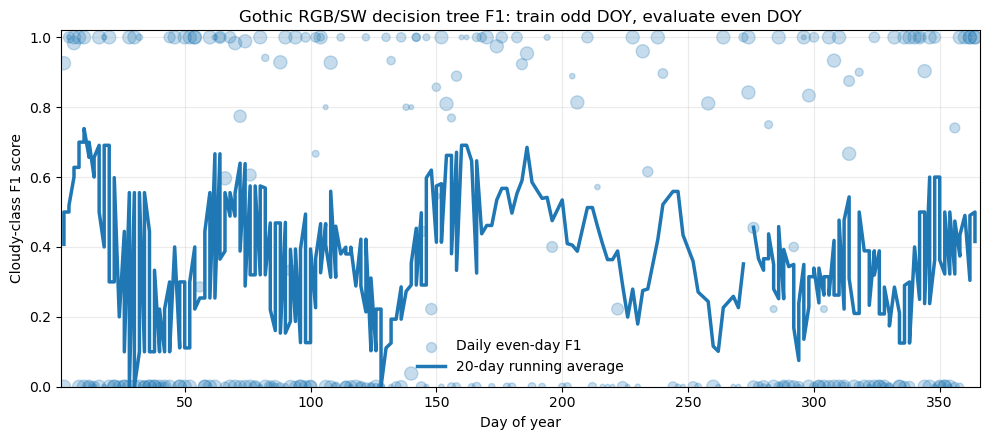

In [8]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/glade/derecho/scratch/cdalden/tmp/matplotlib')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
import matplotlib.pyplot as plt
plot_df = daily_f1.sort_values('day_of_year')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(
    plot_df['day_of_year'],
    plot_df['cloudy_f1'],
    s=np.clip(plot_df['n_samples'] * 3, 12, 90),
    alpha=0.25,
    label='Daily even-day F1',
)
ax.plot(
    plot_df['day_of_year'],
    plot_df['f1_20day_running_avg'],
    color="tab:blue",
    linewidth=2.5,
    label='20-day running average',
)
ax.set_xlim(1, 366)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Day of year')
ax.set_ylabel('Cloudy-class F1 score')
ax.set_title('Gothic RGB/SW decision tree F1: train odd DOY, evaluate even DOY')
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()